https://github.com/jgehrcke/covid-19-germany-gae/blame/master/cases-rki-by-ags.csv

data saved in same folder as other survstat data

## dataprocessing

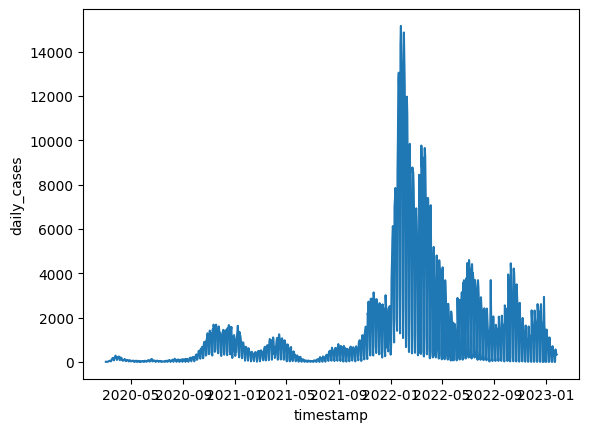

In [47]:
from src.utils import get_data_env
import os 
import pandas as pd
from itertools import product

raw_data = pd.read_csv(os.path.join(get_data_env(),'raw/cases-rki-by-ags.csv'))
raw_data['timestamp'] =  pd.to_datetime(raw_data['time_iso8601']).dt.date
raw_data.drop(columns = ['time_iso8601'], inplace = True)

raw_data_long           =  raw_data.melt(id_vars = 'timestamp', var_name='nuts3', value_name='cases')
raw_data_long['nuts3']  = raw_data_long['nuts3'].str.zfill(5)

# one error in nuts3: 16056 has become part of 16063
raw_data_long.loc[raw_data_long['nuts3'] == '16056', 'nuts3'] = '16063'

# Filter out unwanted nuts3 codes FIRST
filter_nuts = ['11001','11002','11003','11004','11005','11006','11007','11008','11009','11010','11011','11012','sum_cases']
raw_data_long = raw_data_long[~raw_data_long['nuts3'].isin(filter_nuts)]

# Group by timestamp and nuts3
raw_data_long = raw_data_long.groupby(['timestamp','nuts3'])['cases'].sum().reset_index(drop = False)

# NOW create complete index with only the remaining nuts3 codes
all_timestamps = raw_data_long['timestamp'].unique()
all_nuts3 = raw_data_long['nuts3'].unique()

complete_index = pd.DataFrame(
    list(product(all_timestamps, all_nuts3)),
    columns=['timestamp', 'nuts3']
)

# Merge to find missing combinations and fill with 0
raw_data_long = complete_index.merge(
    raw_data_long, 
    on=['timestamp', 'nuts3'], 
    how='left'
)
raw_data_long['cases'] = raw_data_long['cases'].fillna(0)

# Continue with processing
df = raw_data_long.sort_values(['nuts3', 'timestamp'])

df['daily_cases'] = df.groupby('nuts3')['cases'].diff()
df.loc[df['daily_cases'] < 0, 'daily_cases'] = 0
import seaborn as sns
df['timestamp'] = pd.to_datetime(df['timestamp'])
sns.lineplot(df[df['nuts3'] == '11000'], x = 'timestamp', y = 'daily_cases')

preprocessed_data = df[['timestamp','nuts3','daily_cases']].rename(columns = {'daily_cases':'cases','nuts3':'kz_kreis'})
iso = df['timestamp'].dt.isocalendar()

preprocessed_data['year'] = iso.year
preprocessed_data['week'] = iso.week
preprocessed_data['day'] = iso.day

preprocessed_data.loc[preprocessed_data['cases'].isna(), 'cases'] = 0
preprocessed_data.reset_index(drop = True, inplace=True)
preprocessed_data = preprocessed_data[['week','kz_kreis','cases','year','timestamp','day']]
preprocessed_data.to_csv(os.path.join(get_data_env(),'processed/germany/epidemiology/casedata/survstat/covid_daily.csv'), index=False)

## dataloading

In [4]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager, DeepDataLoaderManager
from src.models import ConstantModel, PersistenceModel, ClimateologyModel, NodeLSTMModel, NodeGRUModel, GATv2Model, GATv2LSTMModel, SeqNodeLSTMModel

# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-06-01'
split_valtest   = '2022-09-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 7
sequence_length = 7
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    temporal_frequency   = "d",
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  ,
    weekly_time_index   = False,
    daily_time_index    = True,
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

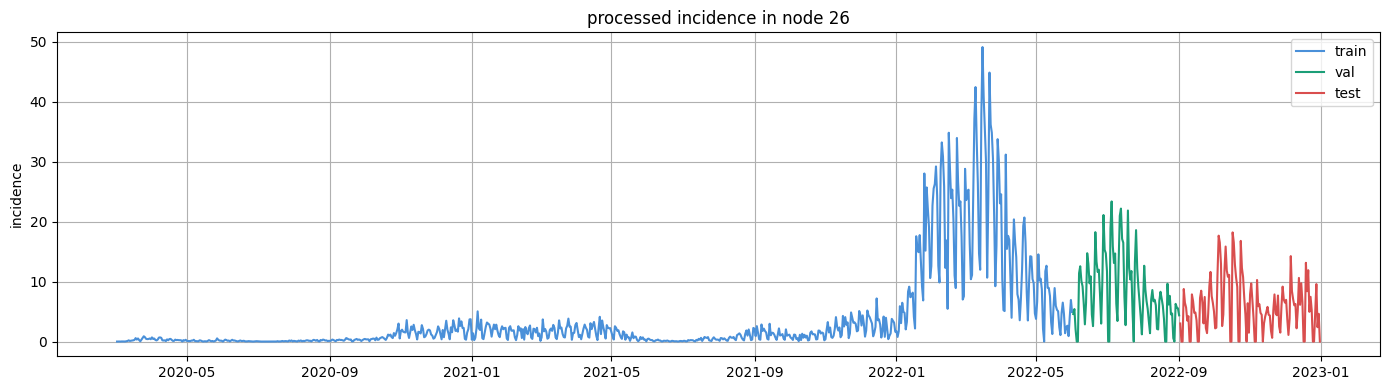

In [5]:
import pandas as pd
data_orchestrator.preview(26).show()

In [6]:
from src.dataloading import ShallowDataLoaderManager, GraphDataLoaderManager, BaseLineDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel

sl = BaseLineDataLoaderManager(data_orchestrator)
dl = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()

gl1 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('identity_graph').construct_dataloaders()
gl2 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()
gl3 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()

ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

f1 = (raw_f1
      .labels.change_suptitle('Persistence model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','persistence model'])
      .change_figsize(10,5).legend.move('upper left'))

f2 = (raw_f2
      .labels.change_suptitle('Climateology model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,5).legend.move('upper left'))

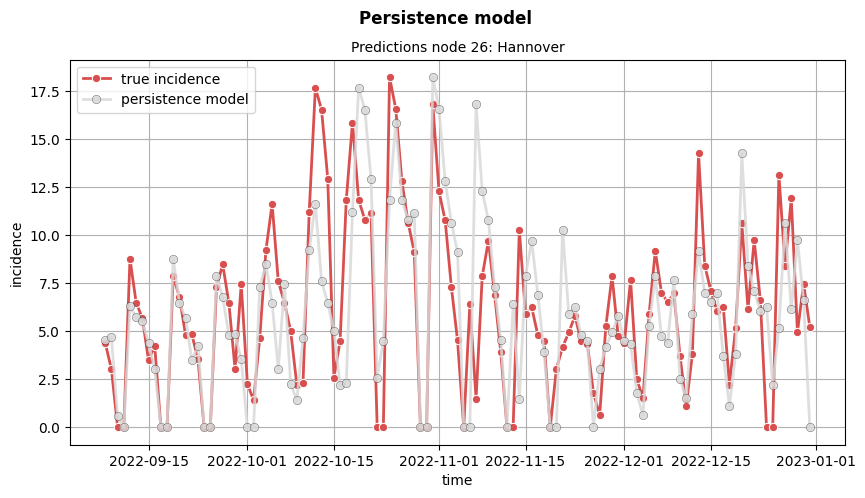

In [10]:
f1.show()

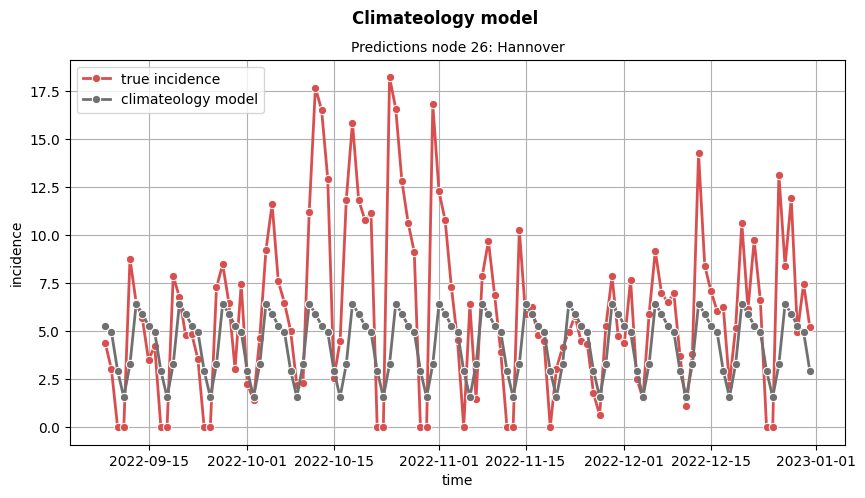

In [9]:
f2.show()


==                lstm_carryover                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 3, 7), y=(400, 1))
Epoch 001 train loss: 0.9428, val loss: 1.3279 ✓ (new best)
Epoch 002 train loss: 0.5581, val loss: 0.3946 ✓ (new best)
Epoch 003 train loss: 0.2809, val loss: 0.3510 ✓ (new best)
Epoch 004 train loss: 0.2469, val loss: 0.3301 ✓ (new best)
Epoch 005 train loss: 0.2303, val loss: 0.3253 ✓ (new best)
Epoch 006 train loss: 0.2198, val loss: 0.3258 (patience: 1/10)
Epoch 007 train loss: 0.2143, val loss: 0.3267 (patience: 2/10)
Epoch 008 train loss: 0.2102, val loss: 0.3284 (patience: 3/10)
Epoch 009 train loss: 0.2079, val loss: 0.3286 (patience: 4/10)
Epoch 010 train loss: 0.2063, val loss: 0.3283 (patience: 5/10)
Epoch 011 train loss: 0.2049, val loss: 0.3280 (patience: 6/10)
Epoch 012 train loss: 0.2045, val loss: 0.3272 (patience: 7/10)
lr has been updated from 1.00e-05 to 5.00e-06
Epoch 013 train loss: 0.2104, val loss: 0.3072 ✓ (new be

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 250 train loss: 0.1512, val loss: 0.1887 (patience: 1/10)
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 573.20it/s]


Test loss: 0.2774
forecasted ✓


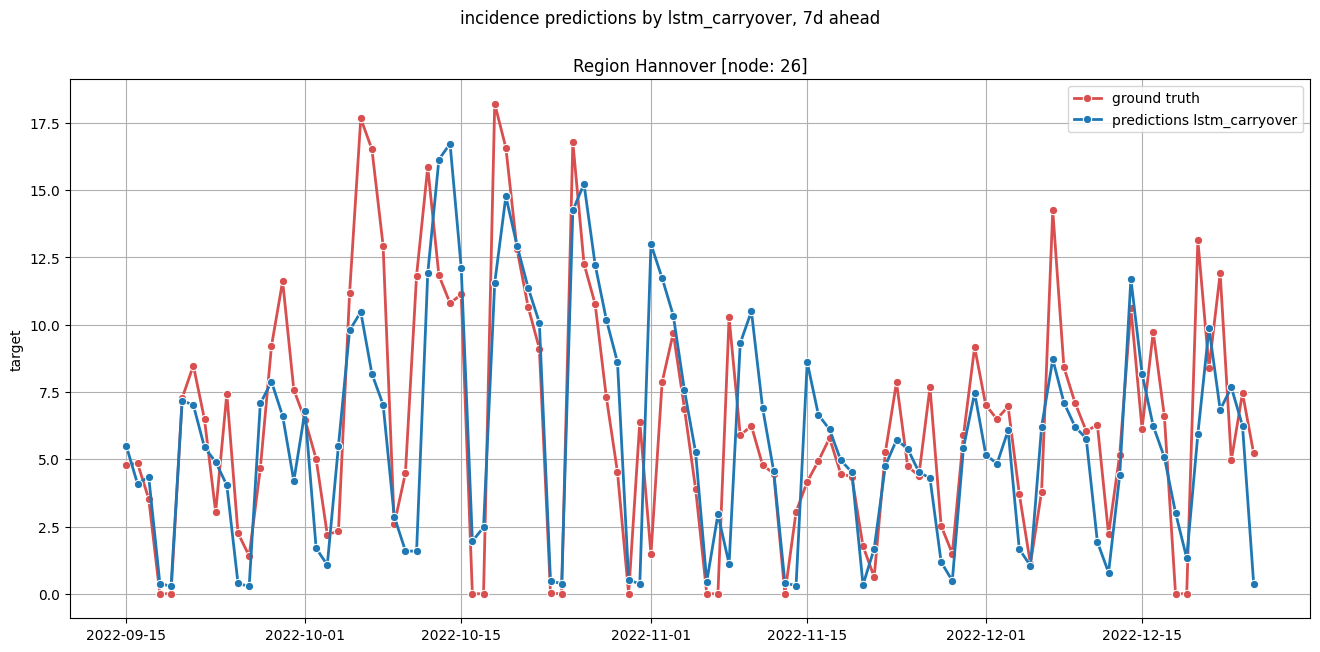

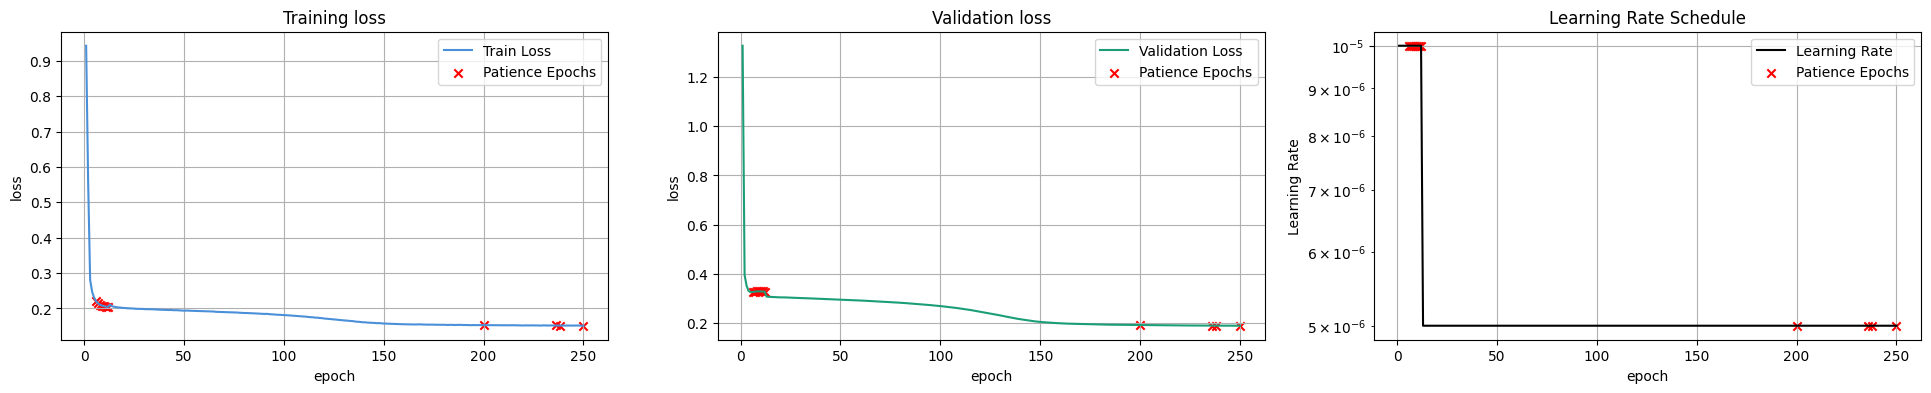

In [12]:
from src.models import NodeLSTMModel

lr = 0.00001

n_epochs= 250
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

lstm = NodeLSTMModel(dl,'lstm_carryover' , verbose = 2)
lstm.set_model_hparams()
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26).show()


==                   lstm_seq                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 3, 7), y=(400, 1))
Epoch 001 train loss: 0.9343, val loss: 1.5013 ✓ (new best)
Epoch 002 train loss: 0.6714, val loss: 1.0927 ✓ (new best)
Epoch 003 train loss: 0.3609, val loss: 1.0343 ✓ (new best)
Epoch 004 train loss: 0.3009, val loss: 1.0137 ✓ (new best)
Epoch 005 train loss: 0.2885, val loss: 0.9881 ✓ (new best)
Epoch 006 train loss: 0.2807, val loss: 0.9636 ✓ (new best)
Epoch 007 train loss: 0.2742, val loss: 0.9402 ✓ (new best)
Epoch 008 train loss: 0.2685, val loss: 0.9176 ✓ (new best)
Epoch 009 train loss: 0.2634, val loss: 0.8956 ✓ (new best)
Epoch 010 train loss: 0.2587, val loss: 0.8742 ✓ (new best)
Epoch 011 train loss: 0.2544, val loss: 0.8534 ✓ (new best)
Epoch 012 train loss: 0.2504, val loss: 0.8331 ✓ (new best)
Epoch 013 train loss: 0.2467, val loss: 0.8135 ✓ (new best)
Epoch 014 train loss: 0.2432, val loss: 0.7947 ✓ (new best)
Epoch 015 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 250 train loss: 0.1403, val loss: 0.1894 ✓ (new best)
trained ✓


Forecasting test: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 2056.37it/s]

Test loss: 0.2642
forecasted ✓


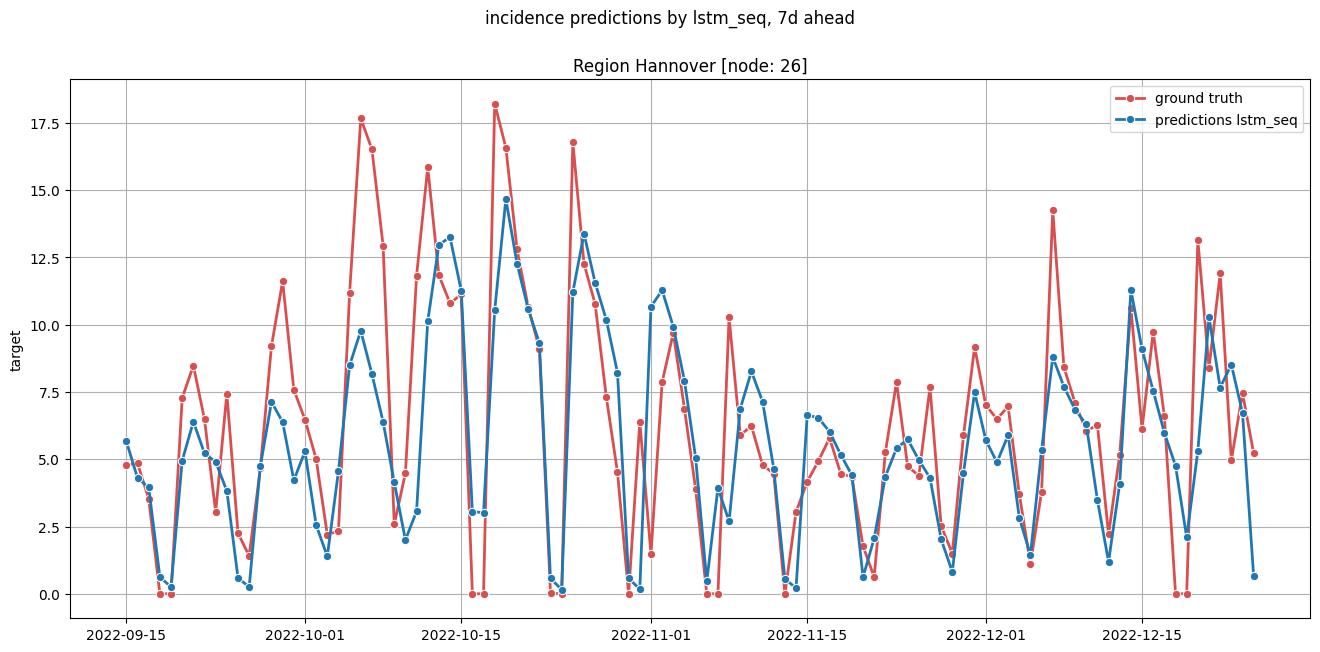

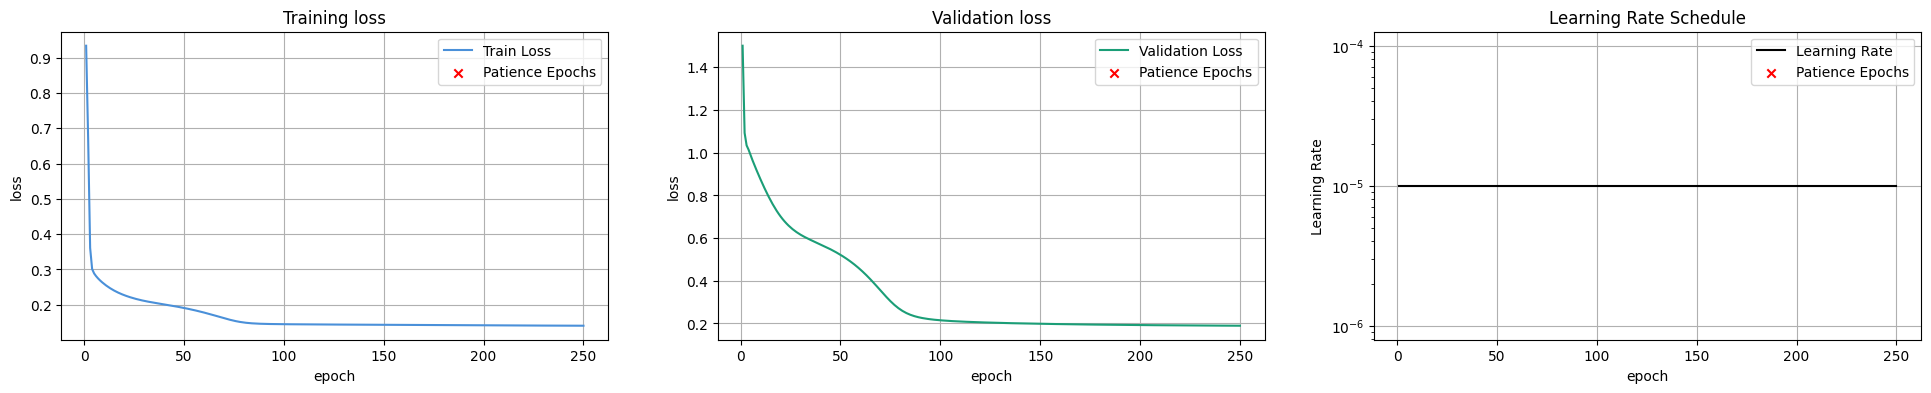

In [13]:
lstm2 = SeqNodeLSTMModel(dl,'lstm_seq' , verbose = 2)
lstm2.set_model_hparams()
lstm2.set_global_hparams(**global_hparams)
lstm2.train()
lstm2.forecast('test')
lstm2.show_forecasts(26).show()


==              gcn_identity_graph              ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.9868, val loss: 1.3169 ✓ (new best)
Epoch 002 train loss: 0.9389, val loss: 1.2383 ✓ (new best)
Epoch 003 train loss: 0.8807, val loss: 1.1348 ✓ (new best)
Epoch 004 train loss: 0.8071, val loss: 1.0100 ✓ (new best)
Epoch 005 train loss: 0.7191, val loss: 0.8697 ✓ (new best)
Epoch 006 train loss: 0.6206, val loss: 0.7195 ✓ (new best)
Epoch 007 train loss: 0.5190, val loss: 0.5697 ✓ (new best)
Epoch 008 train loss: 0.4244, val loss: 0.4326 ✓ (new best)
Epoch 009 train loss: 0.3478, val loss: 0.3248 ✓ (new best)
Epoch 010 train loss: 0.2904, val loss: 0.2516 ✓ (new best)
Epoch 011 train loss: 0.2551, val loss: 0.2115 ✓ (new best)
Epoch 012 train loss: 0.2353, val loss: 0.1942 ✓ (new best)
Epoch 013 train loss: 0.2246, val loss: 0.1885 ✓ (new best)
Epoch 014 train loss: 0.2187

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.1874
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 600.96it/s]


Test loss: 0.2834
forecasted ✓

==              gcn_geo_neighbors               ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.9942, val loss: 1.5339 ✓ (new best)
Epoch 002 train loss: 0.9512, val loss: 1.4802 ✓ (new best)
Epoch 003 train loss: 0.8987, val loss: 1.4116 ✓ (new best)
Epoch 004 train loss: 0.8344, val loss: 1.3248 ✓ (new best)
Epoch 005 train loss: 0.7604, val loss: 1.2184 ✓ (new best)
Epoch 006 train loss: 0.6795, val loss: 1.0930 ✓ (new best)
Epoch 007 train loss: 0.5945, val loss: 0.9508 ✓ (new best)
Epoch 008 train loss: 0.5116, val loss: 0.7998 ✓ (new best)
Epoch 009 train loss: 0.4330, val loss: 0.6538 ✓ (new best)
Epoch 010 train loss: 0.3669, val loss: 0.5285 ✓ (new best)
Epoch 011 train loss: 0.3140, val loss: 0.4323 ✓ (new best)
Epoch 012 train loss: 0.2765, val loss: 0.3676 ✓ (new best)
Epoch 013 train loss: 0.2524, val loss: 0.3309 ✓ (new b

...

Test loss: 0.3275
forecasted ✓

==                 gcn_commuter                 ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.9757, val loss: 1.2586 ✓ (new best)
Epoch 002 train loss: 0.9091, val loss: 1.1794 ✓ (new best)
Epoch 003 train loss: 0.8313, val loss: 1.0822 ✓ (new best)
Epoch 004 train loss: 0.7421, val loss: 0.9654 ✓ (new best)
Epoch 005 train loss: 0.6443, val loss: 0.8324 ✓ (new best)
Epoch 006 train loss: 0.5445, val loss: 0.6878 ✓ (new best)
Epoch 007 train loss: 0.4506, val loss: 0.5474 ✓ (new best)
Epoch 008 train loss: 0.3718, val loss: 0.4243 ✓ (new best)
Epoch 009 train loss: 0.3115, val loss: 0.3284 ✓ (new best)
Epoch 010 train loss: 0.2711, val loss: 0.2642 ✓ (new best)
Epoch 011 train loss: 0.2458, val loss: 0.2279 ✓ (new best)
Epoch 012 train loss: 0.2322, val loss: 0.2107 ✓ (new best)
Epoch 013 train loss: 0.2245, val loss: 0.2037 ✓ (new bes

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 642.49it/s]


Test loss: 0.2837
forecasted ✓


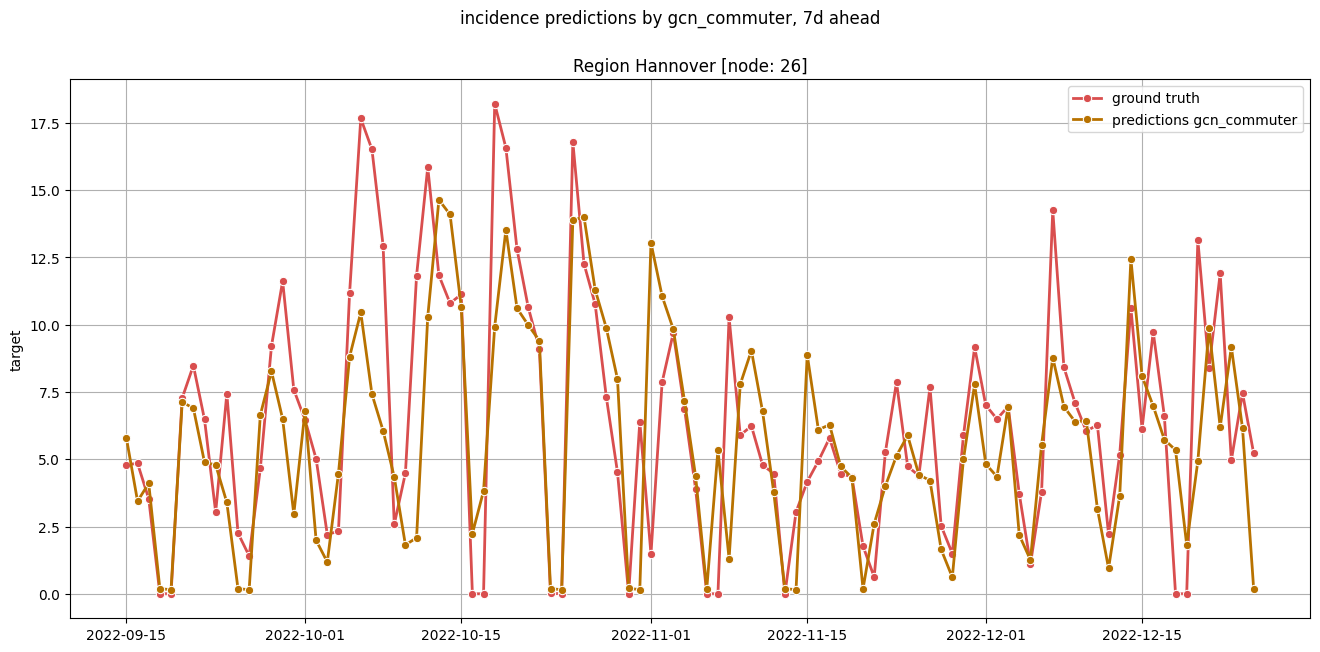

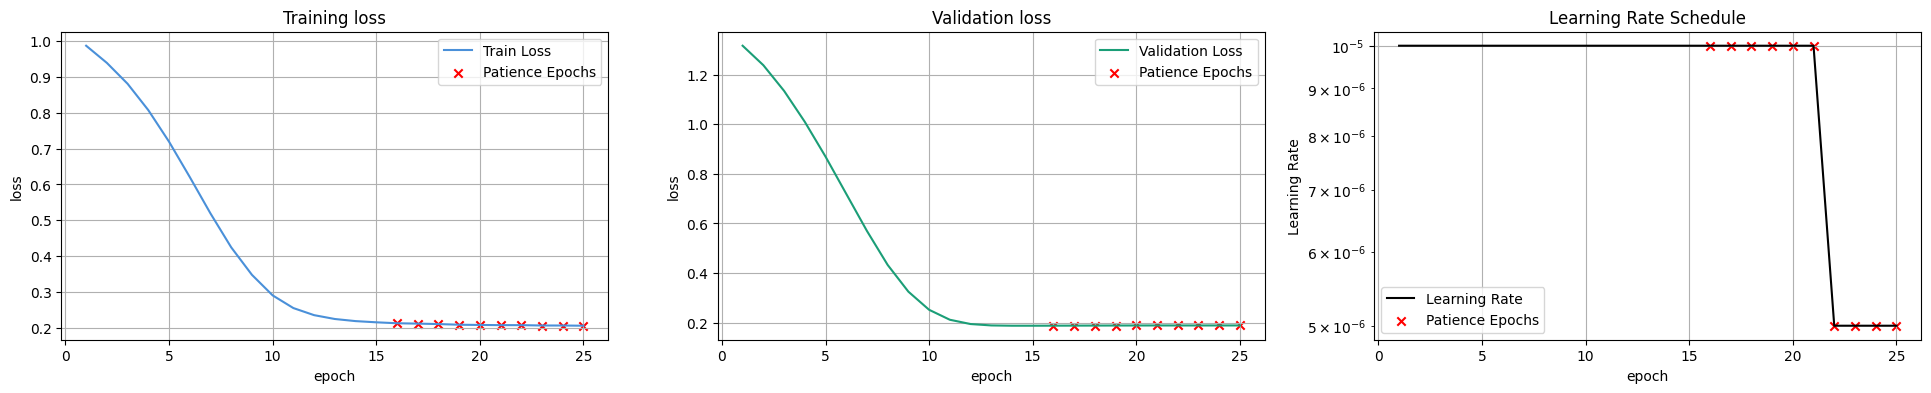

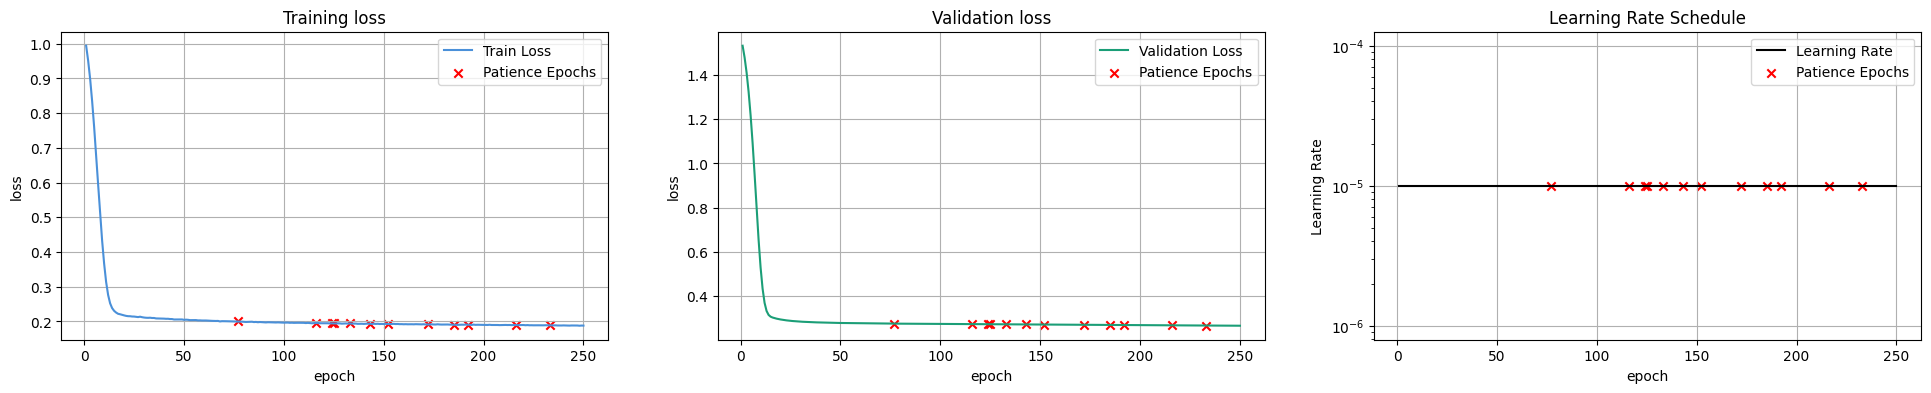

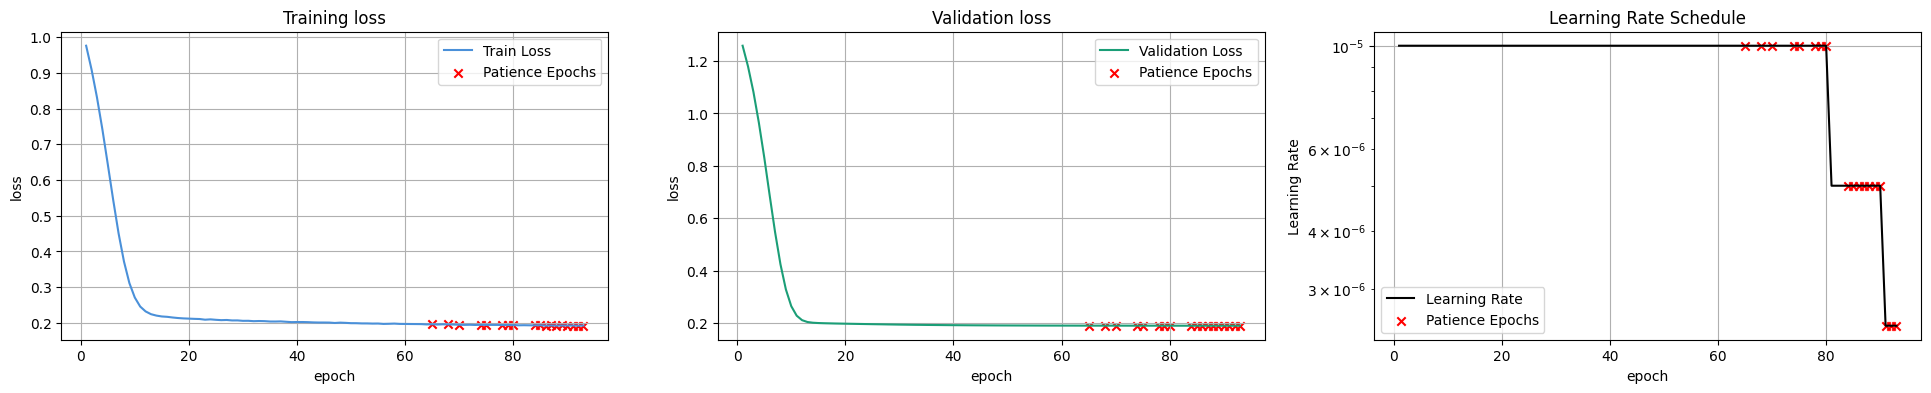

In [14]:
from src.models import SimpleGCNModel

lr = 0.00001

min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gcn1 = SimpleGCNModel(gl1, name='gcn_identity_graph', verbose = 2)
gcn1.set_model_hparams()
gcn1.set_global_hparams(**global_hparams)
gcn1.train()
gcn1.forecast('test')
gcn1.show_forecasts(26).show()

gcn2 = SimpleGCNModel(gl2, name='gcn_geo_neighbors', verbose = 2)
gcn2.set_model_hparams()
gcn2.set_global_hparams(**global_hparams)
gcn2.train()
gcn2.forecast('test')
gcn2.show_forecasts(26).show()

gcn3 = SimpleGCNModel(gl1, name='gcn_commuter', verbose = 2)
gcn3.set_model_hparams()
gcn3.set_global_hparams(**global_hparams)
gcn3.train()
gcn3.forecast('test')
gcn3.show_forecasts(26).show()


==             gatv2_identity_graph             ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.7902, val loss: 0.9603 ✓ (new best)
Epoch 002 train loss: 0.6052, val loss: 0.5636 ✓ (new best)
Epoch 003 train loss: 0.4734, val loss: 0.3348 ✓ (new best)
Epoch 004 train loss: 0.4122, val loss: 0.2509 ✓ (new best)
Epoch 005 train loss: 0.3892, val loss: 0.2297 ✓ (new best)
Epoch 006 train loss: 0.3781, val loss: 0.2253 ✓ (new best)
Epoch 007 train loss: 0.3682, val loss: 0.2279 (patience: 1/10)
Epoch 008 train loss: 0.3613, val loss: 0.2288 (patience: 2/10)
Epoch 009 train loss: 0.3576, val loss: 0.2305 (patience: 3/10)
Epoch 010 train loss: 0.3522, val loss: 0.2313 (patience: 4/10)
Epoch 011 train loss: 0.3479, val loss: 0.2313 (patience: 5/10)
Epoch 012 train loss: 0.3422, val loss: 0.2320 (patience: 6/10)
Epoch 013 train loss: 0.3376, val loss: 0.2336 (patience: 7/10)


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.2250
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 649.33it/s]


Test loss: 0.2936
forecasted ✓

==             gatv2_geo_neighbors              ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.8054, val loss: 1.0019 ✓ (new best)
Epoch 002 train loss: 0.5835, val loss: 0.6440 ✓ (new best)
Epoch 003 train loss: 0.3928, val loss: 0.4083 ✓ (new best)
Epoch 004 train loss: 0.2876, val loss: 0.3060 ✓ (new best)
Epoch 005 train loss: 0.2480, val loss: 0.2721 ✓ (new best)
Epoch 006 train loss: 0.2367, val loss: 0.2609 ✓ (new best)
Epoch 007 train loss: 0.2287, val loss: 0.2571 ✓ (new best)
Epoch 008 train loss: 0.2246, val loss: 0.2557 ✓ (new best)
Epoch 009 train loss: 0.2228, val loss: 0.2552 ✓ (new best)
Epoch 010 train loss: 0.2211, val loss: 0.2551 ✓ (new best)
Epoch 011 train loss: 0.2202, val loss: 0.2549 ✓ (new best)
Epoch 012 train loss: 0.2191, val loss: 0.2549 ✓ (new best)
Epoch 013 train loss: 0.2172, val loss: 0.2550 (patienc

...

Test loss: 0.3146
forecasted ✓

==                gatv2_commuter                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
Epoch 001 train loss: 0.8305, val loss: 1.0540 ✓ (new best)
Epoch 002 train loss: 0.6221, val loss: 0.6845 ✓ (new best)
Epoch 003 train loss: 0.3999, val loss: 0.4011 ✓ (new best)
Epoch 004 train loss: 0.2799, val loss: 0.3056 ✓ (new best)
Epoch 005 train loss: 0.2401, val loss: 0.2806 ✓ (new best)
Epoch 006 train loss: 0.2269, val loss: 0.2726 ✓ (new best)
Epoch 007 train loss: 0.2222, val loss: 0.2691 ✓ (new best)
Epoch 008 train loss: 0.2189, val loss: 0.2675 ✓ (new best)
Epoch 009 train loss: 0.2170, val loss: 0.2666 ✓ (new best)
Epoch 010 train loss: 0.2160, val loss: 0.2663 ✓ (new best)
Epoch 011 train loss: 0.2149, val loss: 0.2661 ✓ (new best)
Epoch 012 train loss: 0.2132, val loss: 0.2660 ✓ (new best)
Epoch 013 train loss: 0.2130, val loss: 0.2658 ✓ (new b

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:248: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 10 epochs
Restored model from best validation loss: 0.2581
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [00:00<00:00, 354.10it/s]


Test loss: 0.3288
forecasted ✓


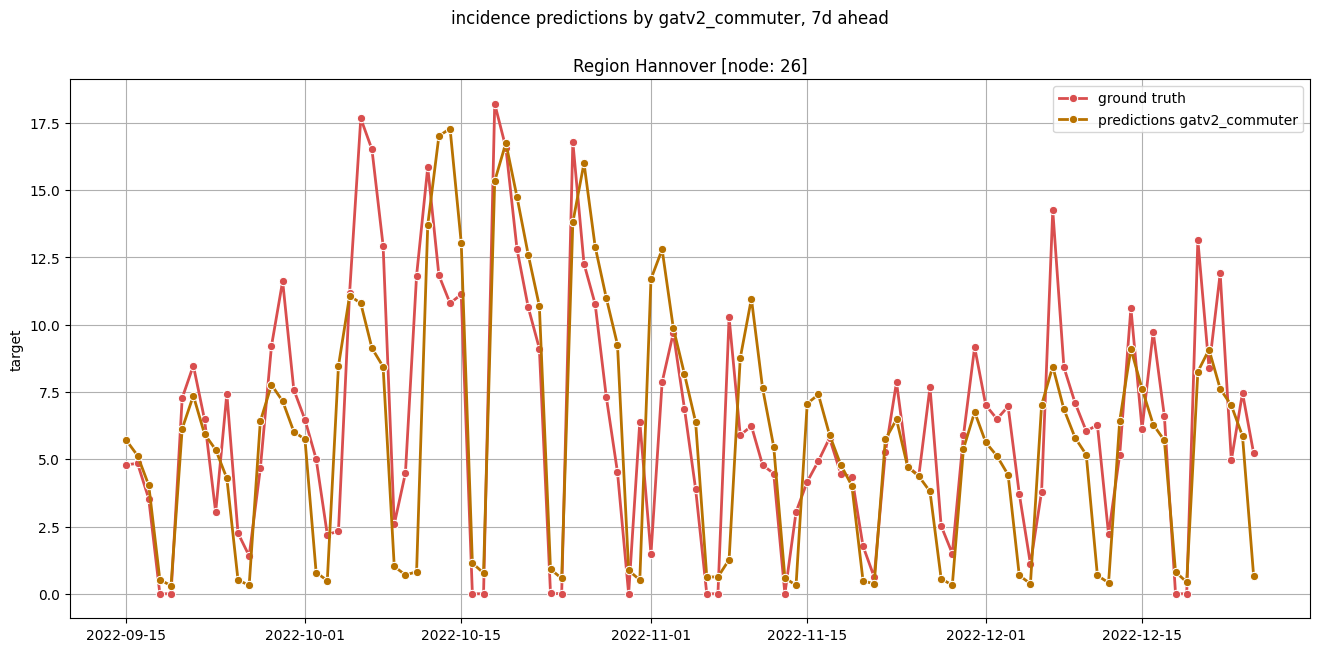

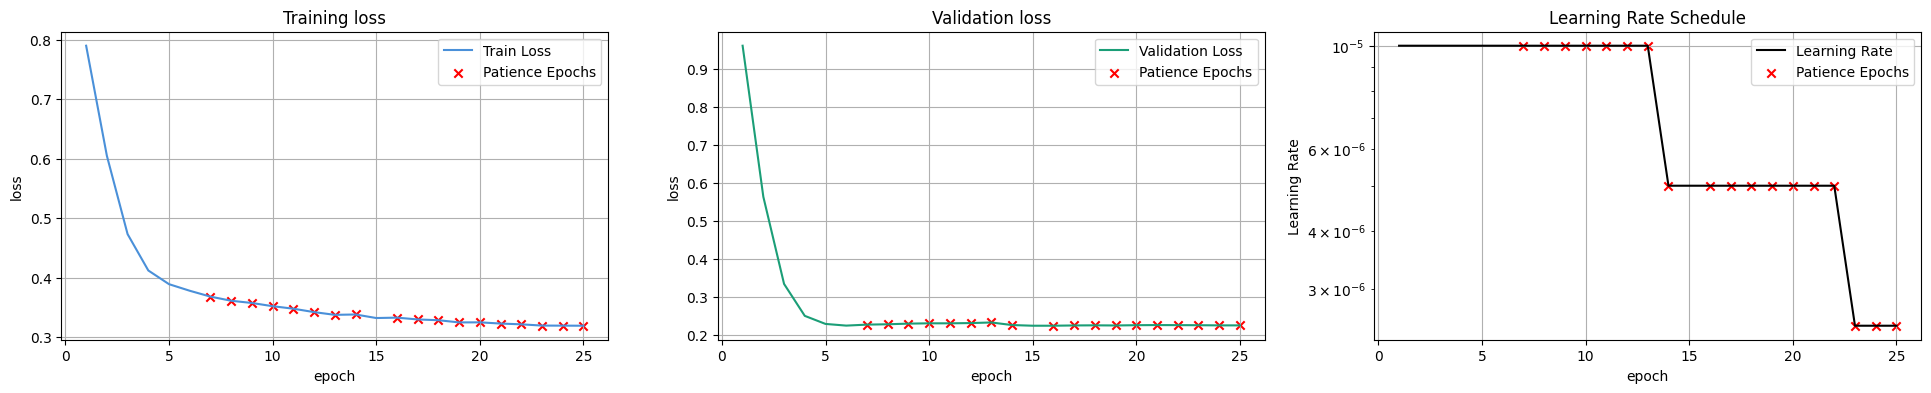

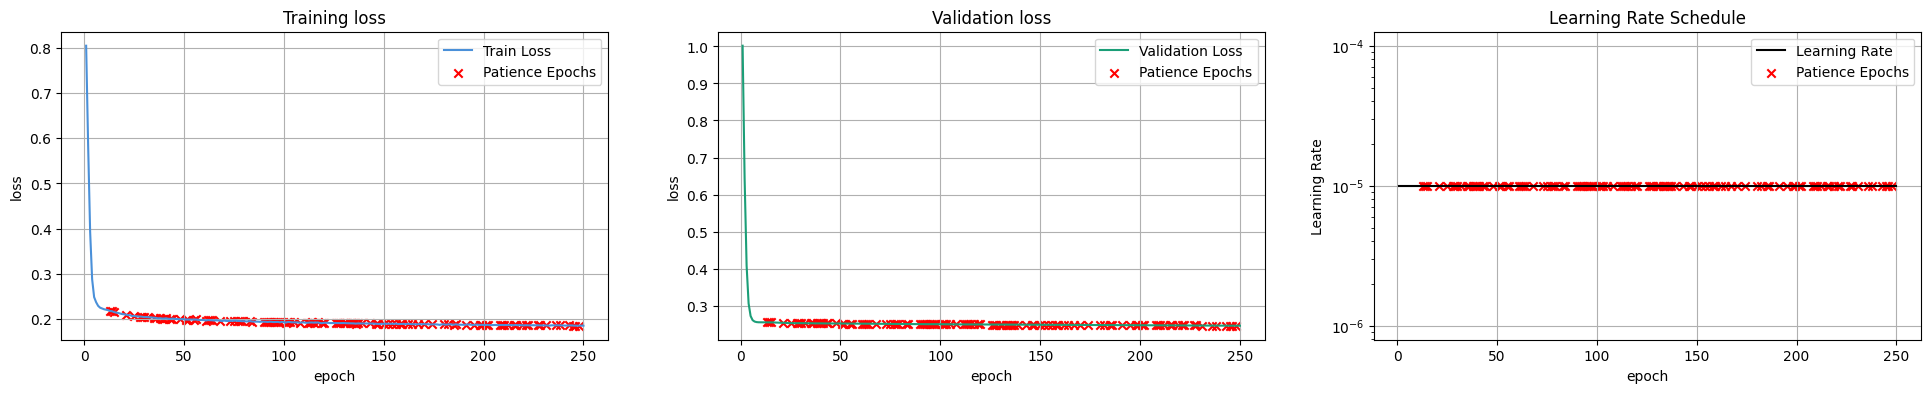

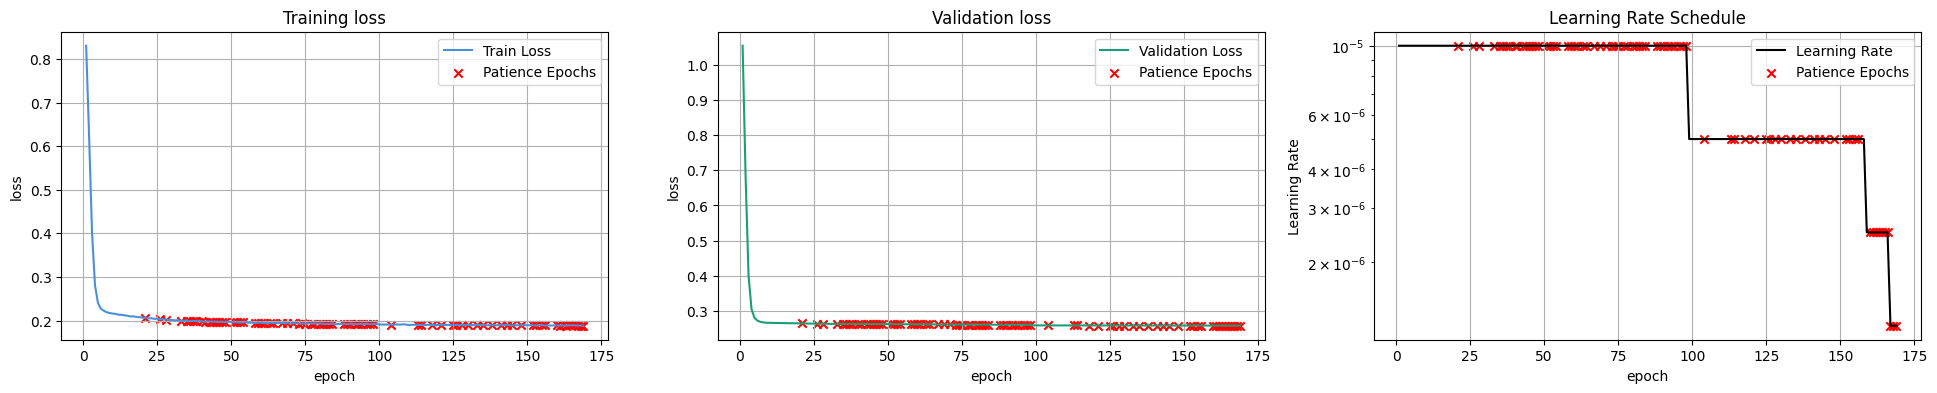

In [15]:
from src.models import GATv2Model

lr = 0.00001
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gat1 = GATv2Model(gl1, name='gatv2_identity_graph', verbose = 2)
gat1.set_model_hparams()
gat1.set_global_hparams(**global_hparams)
gat1.train()
gat1.forecast('test')
gat1.show_forecasts(26).show()

gat2 = GATv2Model(gl2, name='gatv2_geo_neighbors', verbose = 2)
gat2.set_model_hparams()
gat2.set_global_hparams(**global_hparams)
gat2.train()
gat2.forecast('test')
gat2.show_forecasts(26).show()

gat3 = GATv2Model(gl3, name='gatv2_commuter', verbose = 2)
gat3.set_model_hparams()
gat3.set_global_hparams(**global_hparams)
gat3.train()
gat3.forecast('test')
gat3.show_forecasts(26).show()

In [ ]:
lr = 0.00001
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gatlstm1 = GATv2LSTMModel(gl1, name='gatv2lstm_identity_graph', verbose = 2)
gatlstm1.set_model_hparams()
gatlstm1.set_global_hparams(**global_hparams)
gatlstm1.train()
gatlstm1.forecast('test')
gatlstm1.show_forecasts(26).show()

gatlstm2 = GATv2LSTMModel(gl2, name='gatv2lstm_geo_neighbors', verbose = 2)
gatlstm2.set_model_hparams()
gatlstm2.set_global_hparams(**global_hparams)
gatlstm2.train()
gatlstm2.forecast('test')
gatlstm2.show_forecasts(26).show()

gatlstm3 = GATv2LSTMModel(gl3, name='gatv2lstm_commuter', verbose = 2)
gatlstm3.set_model_hparams()
gatlstm3.set_global_hparams(**global_hparams)
gatlstm3.train()
gatlstm3.forecast('test')
gatlstm3.show_forecasts(26).show()


==           gatv2lstm_identity_graph           ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 3, 7), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
Epoch 001 train loss: 0.6067, val loss: 0.9990 ✓ (new best)
Epoch 002 train loss: 0.3737, val loss: 0.8869 ✓ (new best)
Epoch 003 train loss: 0.3114, val loss: 0.7956 ✓ (new best)
Epoch 004 train loss: 0.2862, val loss: 0.6598 ✓ (new best)
Epoch 005 train loss: 0.2642, val loss: 0.5271 ✓ (new best)
Epoch 006 train loss: 0.2460, val loss: 0.4355 ✓ (new best)
Epoch 007 train loss: 0.2341, val loss: 0.3824 ✓ (new best)
Epoch 008 train loss: 0.2225, val loss: 0.3505 ✓ (new best)
Epoch 009 train loss: 0.2173, val loss: 0.3318 ✓ (new best)
Epoch 010 train loss: 0.2100, val loss: 0.3192 ✓ (new best)
Epoch 011 train loss: 0.2058, val loss: 0.3089 ✓ (new best)
Epoch 012 train loss: 0.2023, val loss: 0.3002 ✓ (new best)
Epoch 013 train loss: 0.1986, val loss: 0.2927 ✓ (new best)
Epoch 014 train loss: 0.1971

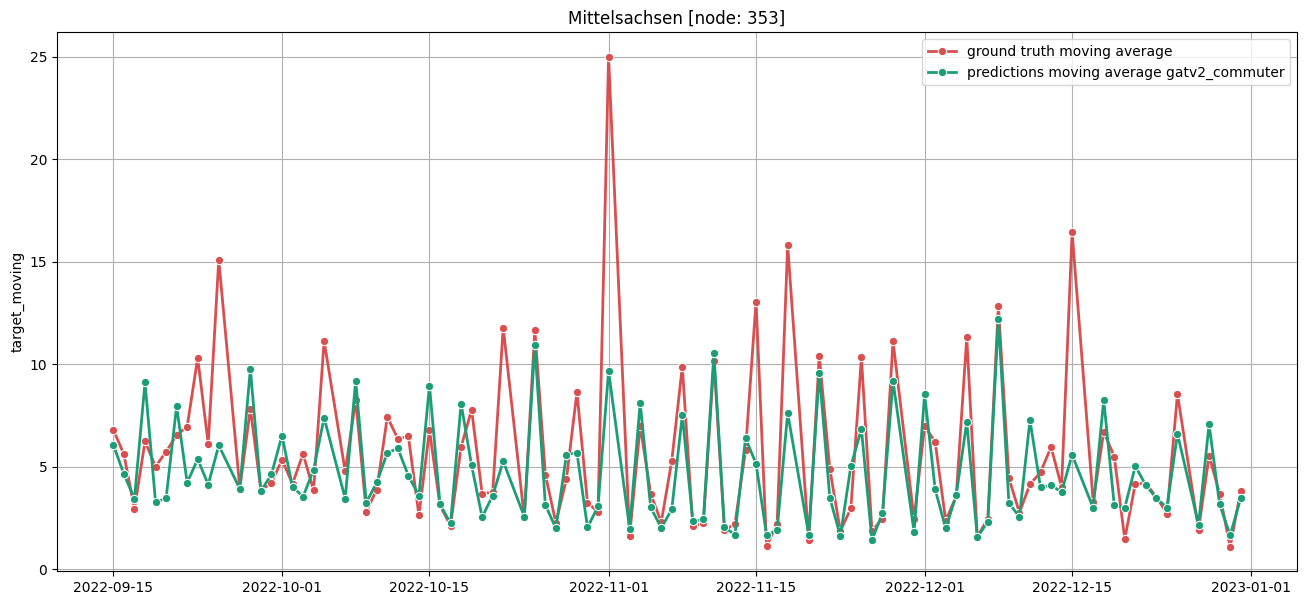

In [ ]:
# import matplotlib.pyplot as plt 
# import seaborn as sns
# from src.utils.colors import color_is_light, testcolor

# node_idx = 353

# moving_average = True



# if isinstance(node_idx, int):
#     node_idx = [node_idx]

# n_plots     = len(node_idx)
# fig, axes   = plt.subplots(n_plots ,1, figsize = (16, 2 + (5 * n_plots)))

# if n_plots > 1:
#     axes        = axes.flatten()           
# else:
#     axes = [axes]

# for counter, id in enumerate(node_idx):
#     ax = axes[counter]
#     nutscode = gat3.tokenization_map['idx_id'][id]
#     nodename = gat3.nutsnames[gat3.nutsnames[f'{gat3.nutslevel}_key'] == nutscode][f'{gat3.nutslevel}_name'].iloc[0]

#     evaluation_df_node  = evaluation_df[evaluation_df['node'] == id]
#     if moving_average:
#         sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'target_moving',    color = testcolor,          marker = 'o',   label = 'ground truth moving average', ax = ax, linewidth = 2)

#     else:
#         sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'target',    color = testcolor,          marker = 'o',   label = 'ground truth', ax = ax, linewidth = 2)

#     # if the luminence of the color is too high for a white background we give a black outline of line and marker
#     if color_is_light(gat3.model_color):                  
#         if moving_average:
#             sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred_moving',color = gat3.model_color,   marker = 'o',   label = f'predictions moving average {gat3.name}',    ax = ax, linewidth = 2, markeredgecolor = 'black', markeredgewidth=0.2)        
#         else:
#             sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred',      color = gat3.model_color,   marker = 'o',   label = f'predictions {gat3.name}',    ax = ax, linewidth = 2, markeredgecolor = 'black', markeredgewidth=0.2)
        
#     else:
#         if moving_average:
#             sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred_moving',color = gat3.model_color,   marker = 'o',   label = f'predictions moving average {gat3.name}',    ax = ax, linewidth = 2)        
#         else:
#             sns.lineplot(data   = evaluation_df_node, x = 'timestamp', y = 'pred',      color = gat3.model_color,   marker = 'o',   label = f'predictions {gat3.name}',    ax = ax, linewidth = 2)
#     ax.set_title(f'{nodename} [node: {id}]')
#     ax.set_xlabel("")            
#     ax.grid()   

In [ ]:
# evaluation_df_node[['pred_moving','target_moving']].corr()

,pred_moving,target_moving
pred_moving,1.000000,0.726098
target_moving,0.726098,1.000000


In [ ]:
# from src.evaluation.metrics import RegressionMetrics

# normal_metrics = RegressionMetrics(target_col = 'target', pred_col = 'pred')
# print(f'ccc predictions {normal_metrics.ccc(evaluation_df_node)}')
# rolling_average_metrics = RegressionMetrics(target_col = 'target_moving', pred_col = 'pred_moving')
# print(f'ccc moving average predictions {rolling_average_metrics.ccc(evaluation_df_node)}')

ccc predictions 0.7142579555511475
ccc moving average predictions 0.5873280213331739


computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:08<00:00,  1.40s/it]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

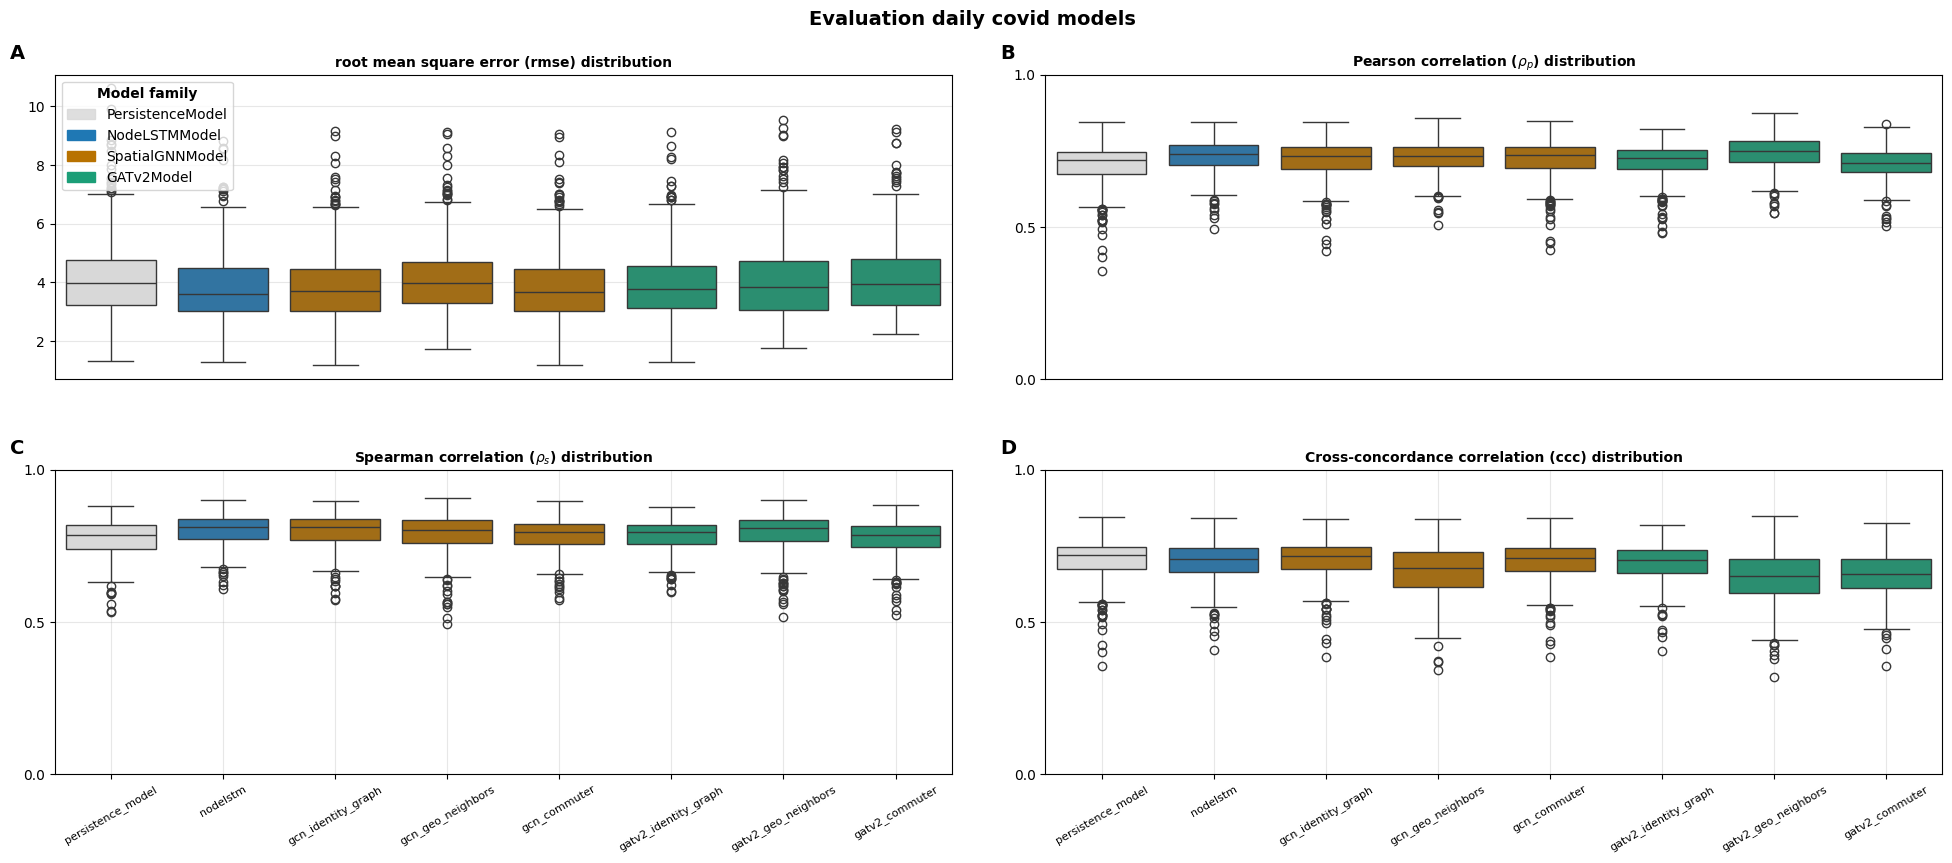

In [ ]:
from src.evaluation import Evaluator

e = Evaluator([ps, lstm, lstm2, gcn1,gcn2,gcn3, gat1, gat2, gat3, gatlstm1, gatlstm2, gatlstm3]).add_evaluation()
raw_figure = e.plotter.plot_metric_compilation(plot_types = ['box','box','box','box'], metrics = ['rmse','pearson_corr','spearman_corr','ccc'])

f_evaluation = (raw_figure
    .labels.change_suptitle(suptitle='Evaluation daily covid models', fontsize = 14, fontweight = 'bold')
    .labels.set_suptitle_y(y=1.05)
    .labels.change_title('root mean square error (rmse) distribution', fontweight = 'bold',         ax = 0)      
    .labels.change_title('Pearson correlation ($\\rho_{p}$) distribution', fontweight = 'bold',     ax = 1)
    .labels.change_title('Spearman correlation ($\\rho_s$) distribution',  fontweight = 'bold',     ax = 2)
    .labels.change_title('Cross-concordance correlation (ccc) distribution', fontweight = 'bold',   ax = 3)    
    .labels.change_ylab('')
    .labels.change_xlab("")
    .ticks.change_xticks([], ax = 0)
    .ticks.change_xticks([], ax = 1)    
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 1)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 2)
    .ticks.change_yticks(ticks = [0,0.5,1], ax = 3)    
    .ticks.rotate_xticks(30)
    .layout.set_ylim([0,1],ax = 1)
    .layout.set_ylim([0,1],ax = 2)
    .layout.set_ylim([0,1],ax = 3)        
    .labels.change_legend_title('Model family',fontweight = 'bold',ax=0)
    .labels.set_tag('A', y = 1.1, ax = 0)   
    .labels.set_tag('B', y = 1.1, ax = 1) 
    .labels.set_tag('C', y = 1.1, ax = 2) 
    .labels.set_tag('D', y = 1.1, ax = 3)      
    .legend.move('upper left', ax = 0)      
    .change_figsize(20,8)         
    )
f_evaluation.show()

In [62]:
metrics = e.metric_compilations.get_compilation('horizon_0','test')

In [63]:
for metric, metric_df in metrics.items():
    print("___________________")
    print(metric)
    for col in metric_df.columns.tolist():
        if col!='node':
            print(f'{col}: {metric_df[col].mean()}')

___________________
mse
persistence_model: 19.186355071375782
nodelstm: 16.373939466178417
gcn_identity_graph: 16.657607402801514
gcn_geo_neighbors: 18.610661624073984
gcn_commuter: 16.460679352283478
gatv2_identity_graph: 17.04978614270687
gatv2_geo_neighbors: 18.367408300042154
gatv2_commuter: 19.126120014190676
___________________
rmse
persistence_model: 4.156524135585141
nodelstm: 3.8537329159260976
gcn_identity_graph: 3.8851747566553057
gcn_geo_neighbors: 4.1422544887999555
gcn_commuter: 3.85855002674493
gatv2_identity_graph: 3.9429135117253757
gatv2_geo_neighbors: 4.054792398384104
gatv2_commuter: 4.18505958253531
___________________
pearson_corr
persistence_model: 0.7031082657571283
nodelstm: 0.7335023409873247
gcn_identity_graph: 0.7206401050090789
gcn_geo_neighbors: 0.7284202471375465
gcn_commuter: 0.7227757561206818
gatv2_identity_graph: 0.7141298928111791
gatv2_geo_neighbors: 0.744790503680706
gatv2_commuter: 0.707204967290163
___________________
spearman_corr
persistence_mo

In [64]:
metric_df

,node,persistence_model,nodelstm,gcn_identity_graph,gcn_geo_neighbors,gcn_commuter,gatv2_identity_graph,gatv2_geo_neighbors,gatv2_commuter
0,0,33.645190,45.836346,36.486702,38.562016,35.682564,37.152100,38.523235,40.454597
1,1,39.465880,38.144695,38.659321,45.895329,38.139423,37.604340,51.841026,44.929459
2,2,36.557744,37.893475,33.222797,42.040863,32.878922,40.195076,43.841736,46.275173
3,3,34.245041,37.930347,35.052608,27.631611,34.283543,39.006279,30.554146,34.989090
4,4,29.194544,35.332199,32.070789,26.979849,30.368620,35.504002,31.518021,32.733341
...,...,...,...,...,...,...,...,...,...
395,395,39.592214,42.235653,43.310432,47.667931,43.977486,43.798820,43.829872,47.654537
396,396,53.162450,56.843067,56.451618,62.362385,56.918907,52.317448,56.548553,56.299477
397,397,58.761174,54.892262,57.688850,55.044682,57.788574,55.137558,52.575630,56.138748
398,398,43.341861,42.272533,41.826500,52.658165,42.664627,39.005531,51.076038,49.379608


In [65]:
ccc['gatv2_commuter'].sort_values()

150    0.289536
60     0.331968
51     0.446896
141    0.481802
156    0.482007
         ...   
265    0.789316
5      0.796617
8      0.807338
260    0.823288
220    0.837360
Name: gatv2_commuter, Length: 400, dtype: float32

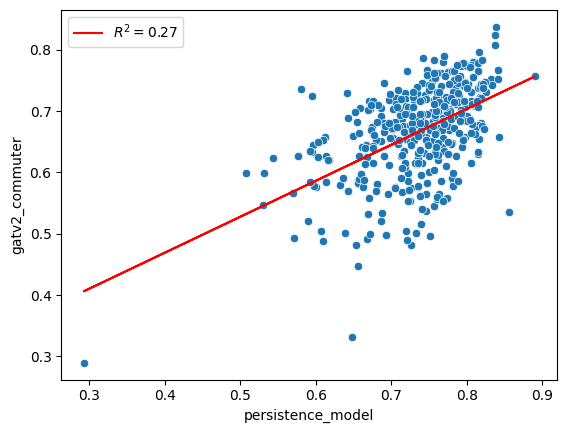

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

model2 = 'gatv2_commuter'
model1 = 'persistence_model'

# scatter plot
sns.scatterplot(data=ccc, x=model1, y=model2)

# fit linear regression
x = ccc[model1]
y = ccc[model2]
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# overlay regression line
plt.plot(x, intercept + slope*x, color='red', label=f'$R^2 = {r_value**2:.2f}$')

plt.legend()
plt.show()
